# CDM 2026 Exploratory Data Analysis (EDA)

> **Objectif** : Comprendre nos données avant de modéliser.  
> On explore les 4 fichiers CSV, on détecte les problèmes, on extrait les insights clés. 
**Dataset** : International Football Results 1872–2026  
**Fichiers** : results.csv · goalscorers.csv · shootouts.csv · former_names.csv

## 0. Imports et configuration

On importe toutes les bibliothèques nécessaires pour l'analyse.

In [2]:
# Manipulation des données 
import pandas as pd       # lire et manipuler les CSV
import numpy as np        # calculs numériques

# Visualisation
import matplotlib.pyplot as plt   # graphiques classiques
import seaborn as sns             # graphiques statistiques plus jolis
import plotly.express as px       # graphiques interactifs
from dotenv import load_dotenv

# Configuration de l'affichage 
pd.set_option('display.max_columns', None)   # afficher toutes les colonnes
pd.set_option('display.max_rows', 50)        # afficher jusqu'à 50 lignes
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 décimales

# Style des graphiques matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Blues_r')

print('Imports OK')

# On charge les credentials AWS depuis le .env
print("Chargement des variables d'environnement...")
load_dotenv("../.env")
print("...fait")

# Chemins S3 vers les données brutes et les données traitées
BUCKET = "fifa-wc-predict-915328198414-eu-west-3-an"
RAW    = f"s3://{BUCKET}/raw"
PROC   = f"s3://{BUCKET}/processed"

Imports OK
Chargement des variables d'environnement...
...fait



## 1. Chargement des données

On lit les 4 fichiers CSV depuis le dossier `data/`.  
On parse les dates directement à la lecture pour éviter de le faire plus tard.

In [ ]:
# Lire les 4 fichiers CSV 
# parse_dates=['date'] = convertir la colonne date en format datetime automatiquement

print("Chargement des fichiers depuis S3...")
results      = pd.read_csv(f"{RAW}/results.csv", parse_dates=['date'])
goals  = pd.read_csv(f"{RAW}/goalscorers.csv", parse_dates=['date'])
shootouts    = pd.read_csv(f"{RAW}/shootouts.csv", parse_dates=['date'])
former = pd.read_csv(f"{RAW}/former_names.csv")
print("...fait")

print('Données chargées')
print(f'   results     : {len(results):,} lignes')
print(f'   goals       : {len(goals):,} lignes')
print(f'   shootouts   : {len(shootouts):,} lignes')
print(f'   former_names: {len(former):,} lignes')

Chargement des fichiers depuis S3...
...fait
Données chargées
   results     : 49,287 lignes
   goals       : 47,601 lignes
   shootouts   : 675 lignes
   former_names: 36 lignes



## 2. Structure des données

On regarde la forme de chaque fichier : colonnes, types, premières lignes.  
C'est la première chose à faire pour comprendre ce qu'on a.

In [12]:
# Structure de results.csv
# fichier principal , une ligne = un match joué

print('RESULTS.CSV')
print(f'Forme : {results.shape}')   # (nb_lignes, nb_colonnes)
print(f'Période : {results.date.min().date()} à {results.date.max().date()}')
print()
print('Types des colonnes :')
print(results.dtypes)
print()
print('5 premières lignes :')
results.head()

RESULTS.CSV
Forme : (49287, 9)
Période : 1872-11-30 à 2026-06-27

Types des colonnes :
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

5 premières lignes :


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.00,0.00,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.00,2.00,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.00,1.00,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.00,2.00,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.00,0.00,Friendly,Glasgow,Scotland,False


In [13]:
# Structure de goalscorers.csv
# Une ligne = un but marqué dans un match
# Contient : buteur, minute, si c'est un penalty ou un CSC

print('GOALSCORERS.CSV')
print(f'Forme : {goals.shape}')
print()
print('Types des colonnes :')
print(goals.dtypes)
print()
print('5 premières lignes :')
goals.head()

GOALSCORERS.CSV
Forme : (47601, 8)

Types des colonnes :
date         datetime64[ns]
home_team            object
away_team            object
team                 object
scorer               object
minute              float64
own_goal               bool
penalty                bool
dtype: object

5 premières lignes :


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.00,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.00,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.00,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.00,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.00,False,False


In [14]:
# Structure de shootouts.csv 
# Une ligne = une séance de tirs au but
# Complète results.csv pour les matchs K.O. qui finissent nuls

print('SHOOTOUTS.CSV')
print(f'Forme : {shootouts.shape}')
print()
print('Types des colonnes :')
print(shootouts.dtypes)
print()
print('5 premières lignes :')
shootouts.head()

SHOOTOUTS.CSV
Forme : (675, 5)

Types des colonnes :
date             datetime64[ns]
home_team                object
away_team                object
winner                   object
first_shooter            object
dtype: object

5 premières lignes :


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [38]:
# Structure de former_names.csv
# Dictionnaire des anciens noms de pays
# Ex : Zaïre à DR Congo, URSS à Russie
# Permet d'éviter de traiter la même équipe comme deux équipes différentes

print('FORMER_NAMES.CSV')
print(f'Forme : {former.shape}')
print()
former

FORMER_NAMES.CSV
Forme : (36, 4)



,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


## 3. Valeurs manquantes (NaN)

On cherche les valeurs manquantes dans chaque fichier.  
Un NaN = une case vide dans le tableau.  

In [40]:
# NaN dans results.csv 
print('NaN dans results.csv')
nan_results = results.isnull().sum()
print(nan_results)
print()

# On regarde quels matchs ont des scores manquants
nan_scores = results[results.home_score.isna()]
print(f'Matchs sans score : {len(nan_scores)}')
print('Tournois concernés :')
print(nan_scores.tournament.value_counts())
print()
# Ces 72 lignes sont les matchs CDM 2026 à prédire !

NaN dans results.csv
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

Matchs sans score : 72
Tournois concernés :
tournament
FIFA World Cup    72
Name: count, dtype: int64



In [42]:
# NaN dans goalscorers.csv 
print('NaN dans goalscorers.csv')
print(goals.isnull().sum())
print()
# scorer NaN = on sait qu'il y a eu un but mais pas qui l'a marqué
# minute NaN = on ne sait pas à quelle minute le but a été marqué
# Non bloquant : on n'a pas besoin du nom du buteur pour nos features
# Pour les features de minutes, on filtrera sur minute.notna()

NaN dans goalscorers.csv
date           0
home_team      0
away_team      0
team           0
scorer        48
minute       256
own_goal       0
penalty        0
dtype: int64



In [44]:
# NaN dans shootouts.csv 
print('NaN dans shootouts.csv')
print(shootouts.isnull().sum())
# first_shooter NaN = on ne sait pas quelle équipe a tiré en premier
# Non bloquant : on utilise surtout la colonne 'winner'

NaN dans shootouts.csv
date               0
home_team          0
away_team          0
winner             0
first_shooter    429
dtype: int64



## 4. Distribution des résultats

On regarde comment les matchs se répartissent entre victoire domicile, nul et victoire extérieur.  
C'est la **variable cible** (target) de notre modèle ML.

In [45]:
# Créer la colonne résultat 
# On filtre post-1990 et on ignore les matchs sans score (CDM 2026)

r90 = results[
    (results.date.dt.year >= 1990) &    # garder seulement les matchs modernes
    (results.home_score.notna())         # ignorer les 72 matchs CDM 2026 sans score
].copy()

# Créer la colonne 'result' : qui a gagné ?
r90['result'] = np.where(
    r90.home_score > r90.away_score, 'home_win',   # l'équipe domicile a marqué plus
    np.where(
        r90.home_score < r90.away_score, 'away_win',  # l'équipe extérieur a marqué plus
        'draw'                                          # même nombre de buts = nul
    )
)

print(f'Matchs post-1990 : {len(r90):,}')
print()
print('Distribution des résultats :')
print(r90.result.value_counts())
print()
print('En pourcentage :')
print(r90.result.value_counts(normalize=True).round(3) * 100)

Matchs post-1990 : 32,101

Distribution des résultats :
result
home_win    15548
away_win     8999
draw         7554
Name: count, dtype: int64

En pourcentage :
result
home_win   48.40
away_win   28.00
draw       23.50
Name: proportion, dtype: float64


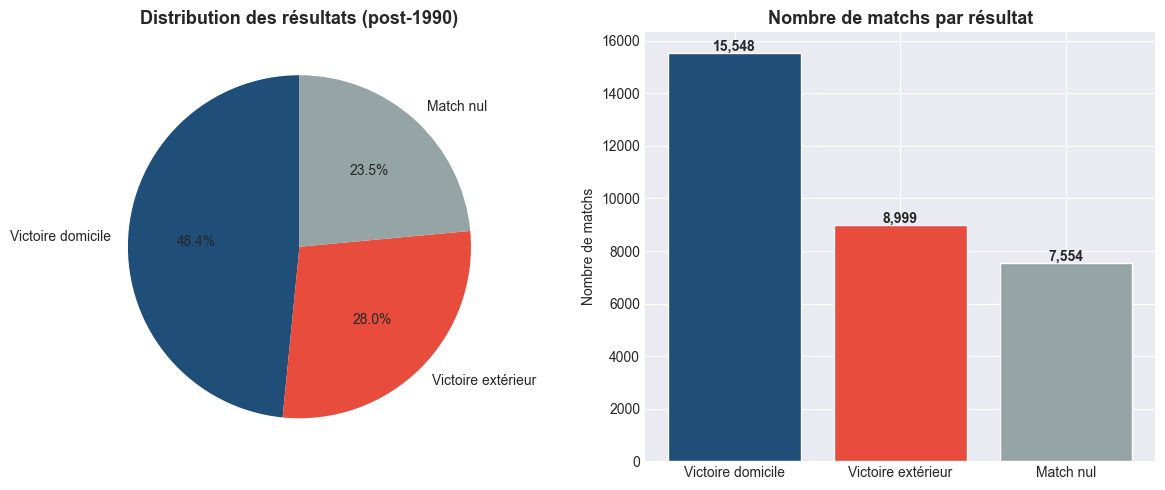

Insight : La classe "draw" est minoritaire  je fais attention au déséquilibre des classes


In [ ]:
# Graphique : distribution des résultats 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : camembert
counts = r90.result.value_counts()
labels = ['Victoire domicile', 'Victoire extérieur', 'Match nul']
colors = ['#1F4E79', '#E74C3C', '#95A5A6']
axes[0].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Distribution des résultats (post-1990)', fontsize=13, fontweight='bold')

# Graphique 2 : barres
axes[1].bar(labels, counts.values, color=colors, edgecolor='white')
axes[1].set_title('Nombre de matchs par résultat', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de matchs')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print('Insight : La classe "draw" est minoritaire je fais attention au déséquilibre des classes')

## 5. Effet du terrain neutre

En CDM 2026, tous les matchs se jouent sur terrain neutre (USA/Canada/Mexique).  
On vérifie si ça change vraiment les résultats.

In [51]:
# Terrain neutre vs terrain réel 
# neutral=False = l'équipe 'home' joue vraiment à domicile
# neutral=True  = terrain neutre, 'home' est juste l'équipe listée en premier

print('EFFET DU TERRAIN NEUTRE')
print()

for neutral_val, label in [(False, 'Terrain réel (domicile)'), (True, 'Terrain neutre')]:
    subset = r90[r90.neutral == neutral_val]
    dist = subset.result.value_counts(normalize=True).round(3)
    print(f'{label} ({len(subset):,} matchs) :')
    print(f'  Victoire home : {dist.get("home_win", 0):.1%}')
    print(f'  Match nul     : {dist.get("draw", 0):.1%}')
    print(f'  Victoire away : {dist.get("away_win", 0):.1%}')
    print()

print('Insight : Sur terrain neutre, l\'avantage domicile tombe de 50.7% à 42.6%')
print('La colonne neutral sera une feature importante pour notre modèle !')

EFFET DU TERRAIN NEUTRE

Terrain réel (domicile) (23,074 matchs) :
  Victoire home : 50.7%
  Match nul     : 23.5%
  Victoire away : 25.8%

Terrain neutre (9,027 matchs) :
  Victoire home : 42.6%
  Match nul     : 23.7%
  Victoire away : 33.7%

Insight : Sur terrain neutre, l'avantage domicile tombe de 50.7% à 42.6%
La colonne neutral sera une feature importante pour notre modèle !


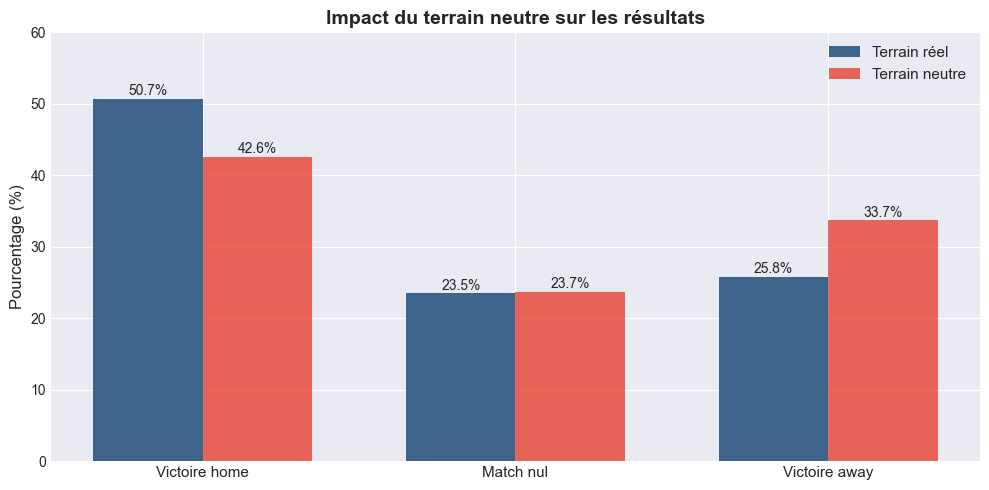

In [ ]:
# Graphique : terrain neutre vs domicile réel
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Victoire home', 'Match nul', 'Victoire away']
domicile   = [50.7, 23.5, 25.8]   # terrain réel
neutre     = [42.6, 23.7, 33.7]   # terrain neutre

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, domicile, width, label='Terrain réel',   color="#2767A2", alpha=0.85)
bars2 = ax.bar(x + width/2, neutre,   width, label='Terrain neutre', color='#E74C3C', alpha=0.85)

ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_title('Impact du terrain neutre sur les résultats', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 60)

# Ajouter les valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Analyse des buts

On analyse les buts : combien par match, à quelle minute, combien de penaltys et de CSC.  
Ça peut servir à construire nos features de style de jeu.

In [ ]:
# Statistiques générales sur les buts 
r90['total_goals'] = r90.home_score + r90.away_score  # total buts par match

print('STATISTIQUES BUTS (post-1990)')
print(f'Moyenne buts/match     : {r90.total_goals.mean():.2f}')
print(f'Buts domicile moy.     : {r90.home_score.mean():.2f}')
print(f'Buts extérieur moy.    : {r90.away_score.mean():.2f}')
print(f'Max buts dans un match : {r90.total_goals.max():.0f}')
print()

# Distribution des scores les plus fréquents
print('Top 10 scores les plus fréquents :')
score_dist = r90.groupby(['home_score', 'away_score']).size().sort_values(ascending=False).head(10)
print(score_dist)

STATISTIQUES BUTS (post-1990)
Moyenne buts/match    : 2.76
Buts domicile moy.    : 1.65
Buts extérieur moy.   : 1.11
Max buts dans un match: 31

Top 10 scores les plus fréquents :
home_score  away_score
1.00        0.00          3562
            1.00          3313
0.00        0.00          2839
2.00        0.00          2646
            1.00          2469
0.00        1.00          2396
1.00        2.00          1656
3.00        0.00          1568
0.00        2.00          1558
2.00        2.00          1213
dtype: int64


In [55]:
#  Analyse des minutes de buts
# On filtre sur minute.notna() car 256 buts n'ont pas de minute renseignée

g90 = goals[
    (goals.date.dt.year >= 1990) &
    (goals.minute.notna())             # on garde seulement les buts avec une minute
].copy()

print(f'Buts avec minute renseignée : {len(g90):,}')
print()

# Découper en intervalles de 15 minutes
bins   = [0, 15, 30, 45, 60, 75, 90, 150]
labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75-90', '90+']
g90['period'] = pd.cut(g90.minute, bins=bins, labels=labels)

print('Buts par période de 15 minutes :')
period_counts = g90.period.value_counts().sort_index()
print(period_counts)
print()
print('Insight : 75-90 min concentre 21% des buts et les équipes marquent plus en fin de match')

Buts avec minute renseignée : 35,149

Buts par période de 15 minutes :
period
0-15     4437
15-30    5007
30-45    5958
45-60    5770
60-75    5894
75-90    7919
90+       164
Name: count, dtype: int64

Insight : 75-90 min concentre 21% des buts et les équipes marquent plus en fin de match


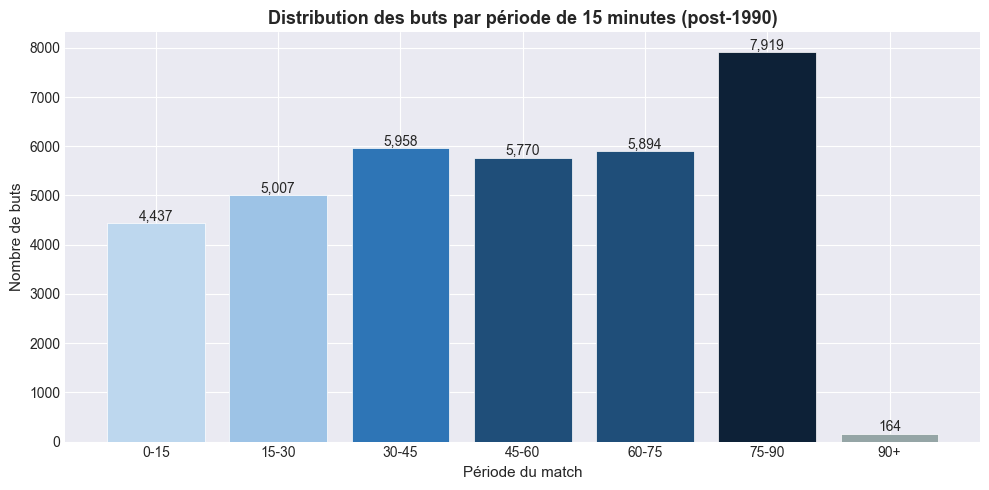

In [56]:
# Graphique : buts par période 
fig, ax = plt.subplots(figsize=(10, 5))

colors_bars = ['#BDD7EE', '#9DC3E6', '#2E75B6', '#1F4E79', '#1F4E79', '#0D2137', '#95A5A6']
bars = ax.bar(labels, period_counts.values, color=colors_bars, edgecolor='white', linewidth=0.5)

ax.set_title('Distribution des buts par période de 15 minutes (post-1990)', fontsize=13, fontweight='bold')
ax.set_xlabel('Période du match', fontsize=11)
ax.set_ylabel('Nombre de buts', fontsize=11)

# Ajouter les valeurs
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Penaltys et CSC
# Ces stats vont servir à créer des features de style de jeu

print('PENALTYS ET CSC (post-1990)')
print()

total_buts = len(g90)
nb_pen = g90.penalty.sum()    # nombre de buts sur penalty
nb_csc = g90.own_goal.sum()   # nombre de buts contre son camp

print(f'Total buts analysés : {total_buts:,}')
print(f'Penaltys            : {nb_pen:,} ({nb_pen/total_buts:.1%} des buts)')
print(f'CSC (contre son camp): {nb_csc:,} ({nb_csc/total_buts:.1%} des buts)')
print()
print('Insight : 7. 4% des buts viennent de penaltys')
print('   Le taux de penaltys obtenus/concédés sera une feature utile')

PENALTYS ET CSC (post-1990)

Total buts analysés : 35,149
Penaltys            : 2,602 (7.4% des buts)
CSC (contre son camp): 763 (2.2% des buts)

Insight : 6.8% des buts viennent de penaltys
   → Le taux de penaltys obtenus/concédés sera une feature utile



## 7. Analyse par tournoi

On compare les résultats selon le type de compétition.  
La CDM se comporte différemment des amicaux ou des qualifications.

In [ ]:
#  Résultats par grand tournoi 
tournois = {
    'FIFA World Cup'          : 'CDM',
    'Friendly'                : 'Amical',
    'UEFA Euro'               : 'Euro',
    'Copa América'            : 'Copa América',
    'African Cup of Nations'  : 'CAN',
    'UEFA Nations League'     : 'Nations League'
}

print('RÉSULTATS PAR TOURNOI (post-1990)')
print(f'{"Tournoi":<20} {"Matchs":>8} {"Home Win":>10} {"Draw":>8} {"Away Win":>10} {"Buts/Match":>12}')
print('-' * 70)

for tournoi, label in tournois.items():
    sub = r90[r90.tournament == tournoi]
    if len(sub) == 0:
        continue
    res  = sub.result.value_counts(normalize=True)
    buts = sub.total_goals.mean()
    print(
        f'{label:<20}'
        f'{len(sub):>8,}'
        f'{res.get("home_win",0):>10.1%}'
        f'{res.get("draw",0):>8.1%}'
        f'{res.get("away_win",0):>10.1%}'
        f'{buts:>12.2f}'
    )

print()
print('Insight : La CDM produit plus de victoires extérieures (31.7%) que les amicaux (25.4%)')
print('  Les matchs à élimination directe sont plus ouverts et imprévisibles')

=== RÉSULTATS PAR TOURNOI (post-1990) ===
Tournoi                Matchs   Home Win     Draw   Away Win   Buts/Match
----------------------------------------------------------------------
CDM                      552     44.7%   23.6%     31.7%        2.52
Amical                10,697     47.4%   27.2%     25.4%        2.55
Euro                     323     38.7%   26.9%     34.4%        2.41
Copa América             378     48.9%   26.7%     24.3%        2.57
CAN                      642     44.2%   28.8%     26.9%        2.26
Nations League           658     43.0%   25.1%     31.9%        2.51

Insight : La CDM produit plus de victoires extérieures (31.7%) que les amicaux (25.4%)
  Les matchs à élimination directe sont plus ouverts et imprévisibles


In [61]:
# Top tournois par nombre de matchs
print('Top 15 tournois dans le dataset :')
print(results.tournament.value_counts().head(15))

Top 15 tournois dans le dataset :
tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64



## 8. CDM 2026

On analyse spécifiquement les 72 matchs CDM 2026 qui sont dans notre dataset.  
Ce sont exactement les matchs à prédire et leurs scores sont à NaN.

In [64]:
# Isoler les matchs CDM 2026 
# Ce sont les lignes avec home_score avec NaN dans results.csv

cdm2026 = results[
    (results.tournament == 'FIFA World Cup') &
    (results.date.dt.year == 2026)
].copy()

print(f'Matchs CDM 2026 : {len(cdm2026)}')
print(f'Tous sur terrain neutre : {cdm2026.neutral.all()}')  # True = tous neutral
print()
print('Dates des matchs :')
print(f'  Premier match : {cdm2026.date.min().date()}')
print(f'  Dernier match : {cdm2026.date.max().date()}')
print()
print('Équipes présentes :')
teams = sorted(set(cdm2026.home_team.tolist() + cdm2026.away_team.tolist()))
print(f'{len(teams)} équipes : {teams}')

Matchs CDM 2026 : 72
Tous sur terrain neutre : False

Dates des matchs :
  Premier match : 2026-06-11
  Dernier match : 2026-06-27

Équipes présentes :
48 équipes : ['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia', 'Croatia', 'Curaçao', 'Czech Republic', 'DR Congo', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Haiti', 'Iran', 'Iraq', 'Ivory Coast', 'Japan', 'Jordan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Panama', 'Paraguay', 'Portugal', 'Qatar', 'Saudi Arabia', 'Scotland', 'Senegal', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Tunisia', 'Turkey', 'United States', 'Uruguay', 'Uzbekistan']


In [62]:
# Afficher les 72 matchs à prédire 
print('Les 72 matchs CDM 2026 à prédire :')
cdm2026[['date', 'home_team', 'away_team', 'neutral']].to_string(index=False)

Les 72 matchs CDM 2026 à prédire :


'      date              home_team              away_team  neutral\n2026-06-11                 Mexico           South Africa    False\n2026-06-11            South Korea         Czech Republic     True\n2026-06-12                 Canada Bosnia and Herzegovina    False\n2026-06-12          United States               Paraguay    False\n2026-06-13                  Qatar            Switzerland     True\n2026-06-13                 Brazil                Morocco     True\n2026-06-13                  Haiti               Scotland     True\n2026-06-13              Australia                 Turkey     True\n2026-06-14                Germany                Curaçao     True\n2026-06-14            Ivory Coast                Ecuador     True\n2026-06-14            Netherlands                  Japan     True\n2026-06-14                 Sweden                Tunisia     True\n2026-06-15                Belgium                  Egypt     True\n2026-06-15                   Iran            New Zealand     


##  9. Détection des anomalies

On cherche les problèmes dans le dataset : doublons, scores aberrants, incohérences.

In [65]:
# Doublons
# Un doublon = même date, mêmes équipes, mais scores différents

doublons = results[results.duplicated(subset=['date', 'home_team', 'away_team'], keep=False)]
print(f'Doublons trouvés : {len(doublons)}')
if len(doublons) > 0:
    print(doublons.to_string())

Doublons trouvés : 2
           date home_team      away_team  home_score  away_score tournament     city country  neutral
9637 1974-02-17    Tahiti  New Caledonia        2.00        1.00   Friendly  Papeete  Tahiti    False
9638 1974-02-17    Tahiti  New Caledonia        1.00        2.00   Friendly  Papeete  Tahiti    False


In [67]:
# Scores aberrants
# On cherche les matchs avec des scores très élevés (> 20 buts)
# Ces matchs sont réels mais peuvent biaiser nos features

r_clean = results.dropna(subset=['home_score'])
outliers = r_clean[(r_clean.home_score > 20) | (r_clean.away_score > 20)]

print(f'Matchs avec score > 20 buts : {len(outliers)}')
print()
print(outliers[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']].to_string())
print()
print('Insight : Ces matchs sont réels (ex: Australie 31-0 Samoa américaines)')
print('   On les garde mais on cappera les features de buts au percentile 99')

Matchs avec score > 20 buts : 7

            date  home_team       away_team  home_score  away_score                    tournament
6576  1966-04-03      Libya            Oman       21.00        0.00                      Arab Cup
8547  1971-09-13     Tahiti    Cook Islands       30.00        0.00           South Pacific Games
11912 1979-08-30       Fiji        Kiribati       24.00        0.00           South Pacific Games
25417 2001-04-09  Australia           Tonga       22.00        0.00  FIFA World Cup qualification
25420 2001-04-11  Australia  American Samoa       31.00        0.00  FIFA World Cup qualification
29040 2005-03-11       Guam     North Korea        0.00       21.00             EAFF Championship
30513 2006-11-24      Sápmi          Monaco       21.00        1.00                Viva World Cup

Insight : Ces matchs sont réels (ex: Australie 31-0 Samoa américaines)
   On les garde mais on cappera les features de buts au percentile 99


In [70]:
#  Vérification former_names 
# On vérifie si des anciens noms subsistent encore dans results.csv

all_teams = set(results.home_team.unique()) | set(results.away_team.unique())
anciens_noms_presents = []

for _, row in former.iterrows():
    if row['former'] in all_teams:
        anciens_noms_presents.append(row['former'])

if len(anciens_noms_presents) == 0:
    print('Aucun ancien nom trouvé avec le dataset est déjà normalisé')
else:
    print(f' Anciens noms encore présents : {anciens_noms_presents}')

Aucun ancien nom trouvé avec le dataset est déjà normalisé



## 10. Évolution temporelle

On regarde comment le football a évolué au fil des décennies.  
Ça justifie notre choix de ne garder que les matchs post-1990.

In [71]:
# Évolution par décennie 
r_all = results.dropna(subset=['home_score']).copy()
r_all['decade'] = (r_all.date.dt.year // 10) * 10   # arrondir à la décennie
r_all['result'] = np.where(
    r_all.home_score > r_all.away_score, 'home_win',
    np.where(r_all.home_score < r_all.away_score, 'away_win', 'draw')
)
r_all['total_goals'] = r_all.home_score + r_all.away_score

# Agréger par décennie
decade_stats = r_all.groupby('decade').agg(
    nb_matchs    = ('result', 'count'),
    home_win_pct = ('result', lambda x: (x == 'home_win').mean()),
    draw_pct     = ('result', lambda x: (x == 'draw').mean()),
    away_win_pct = ('result', lambda x: (x == 'away_win').mean()),
    avg_goals    = ('total_goals', 'mean')
).round(3)

print('Statistiques par décennie :')
print(decade_stats.to_string())

Statistiques par décennie :
        nb_matchs  home_win_pct  draw_pct  away_win_pct  avg_goals
decade                                                            
1870           13          0.61      0.15          0.23       4.54
1880           55          0.49      0.09          0.42       5.58
1890           59          0.51      0.15          0.34       5.15
1900          137          0.45      0.17          0.37       4.18
1910          330          0.55      0.16          0.29       4.22
1920          828          0.53      0.18          0.29       3.88
1930         1079          0.53      0.16          0.32       4.32
1940          833          0.53      0.15          0.31       4.34
1950         1651          0.49      0.18          0.33       4.00
1960         2971          0.52      0.20          0.28       3.48
1970         4133          0.50      0.22          0.28       2.98
1980         5025          0.47      0.26          0.27       2.53
1990         6944          0.50   

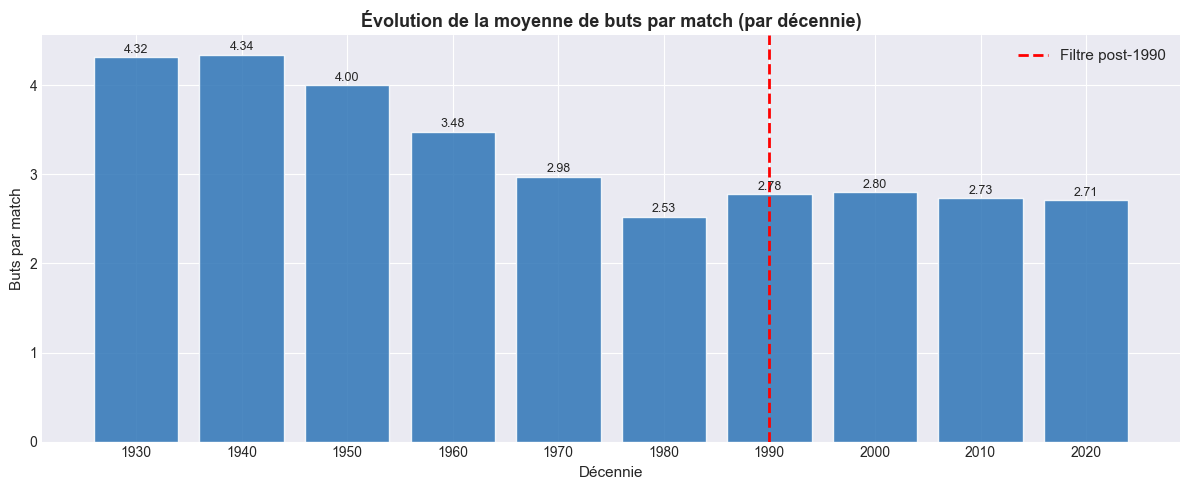

 Insight : Le football moderne (post-1990) est différent — moins de buts, plus tactique
   On entraîne le modèle uniquement sur les données post-1990


In [73]:
#  Graphique : évolution des buts par décennie 
fig, ax = plt.subplots(figsize=(12, 5))

decades = decade_stats.index[decade_stats.index >= 1930]  # depuis 1930
avg_goals_filtered = decade_stats.loc[decades, 'avg_goals']

ax.bar(decades.astype(str), avg_goals_filtered.values, color='#2E75B6', alpha=0.85, edgecolor='white')
ax.axvline(x='1990', color='red', linestyle='--', linewidth=2, label='Filtre post-1990')

ax.set_title('Évolution de la moyenne de buts par match (par décennie)', fontsize=13, fontweight='bold')
ax.set_xlabel('Décennie', fontsize=11)
ax.set_ylabel('Buts par match', fontsize=11)
ax.legend(fontsize=11)

for i, (dec, val) in enumerate(zip(decades, avg_goals_filtered.values)):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(' Insight : Le football moderne (post-1990) est différent — moins de buts, plus tactique')
print('   On entraîne le modèle uniquement sur les données post-1990')

## 11. Résumé des insights EDA

Ce qu'on a appris et ce que ça implique pour la suite.

In [77]:
# Résumé complet 
print('=' * 60)
print('RÉSUMÉ EDA — INSIGHTS CLÉS')
print('=' * 60)
print()
print(' DATASET')
print(f'   {len(results):,} matchs au total (1872–2026)')
print(f'   {len(r90):,} matchs post-1990 (notre set d\'entraînement)')
print(f'   72 matchs CDM 2026 à prédire (scores NaN)')
print()
print('TARGET (variable à prédire)')
print('   home_win : 48.3%  ← classe majoritaire')
print('   away_win : 28.0%')
print('   draw     : 23.7%  ← classe minoritaire')
print('   → Déséquilibre à gérer avec class_weight="balanced"')
print()
print('TERRAIN NEUTRE')
print('   Terrain réel → home_win : 50.7%')
print('   Terrain neutre → home_win : 42.6%')
print('   → Feature critique : colonne neutral')
print('   → CDM 2026 = 100% terrain neutre')
print()
print(' BUTS')
print('   Moyenne : 2.76 buts/match')
print('   21% des buts tombent entre 75-90 min')
print('   6.8% des buts sont des penaltys')
print()
print(' NETTOYAGE NÉCESSAIRE')
print('   1. Isoler les 72 matchs CDM 2026')
print('   2. Filtrer post-1990')
print('   3. Supprimer le doublon Tahiti-Nouvelle Calédonie')
print('   4. Former names : déjà normalisé ')
print('   5. Cap features buts au percentile 99')
print()


RÉSUMÉ EDA — INSIGHTS CLÉS

 DATASET
   49,287 matchs au total (1872–2026)
   32,101 matchs post-1990 (notre set d'entraînement)
   72 matchs CDM 2026 à prédire (scores NaN)

TARGET (variable à prédire)
   home_win : 48.3%  ← classe majoritaire
   away_win : 28.0%
   draw     : 23.7%  ← classe minoritaire
   → Déséquilibre à gérer avec class_weight="balanced"

TERRAIN NEUTRE
   Terrain réel → home_win : 50.7%
   Terrain neutre → home_win : 42.6%
   → Feature critique : colonne neutral
   → CDM 2026 = 100% terrain neutre

 BUTS
   Moyenne : 2.76 buts/match
   21% des buts tombent entre 75-90 min
   6.8% des buts sont des penaltys

 NETTOYAGE NÉCESSAIRE
   1. Isoler les 72 matchs CDM 2026
   2. Filtrer post-1990
   3. Supprimer le doublon Tahiti-Nouvelle Calédonie
   4. Former names : déjà normalisé 
   5. Cap features buts au percentile 99

